# PLCTestbench

In [1]:
from plctestbench.settings import *
from plctestbench.plc_testbench import PLCTestbench
from plctestbench.loss_simulator import BinomialPLS, GilbertElliotPLS, MetronomePLS, CustomMaskPLS
from plctestbench.plc_algorithm import (
    AdvancedPLC,
    ZerosPLC,
    LastPacketPLC,
    LowCostPLC,
    BurgPLC,
    ExternalPLC,
    VermaPLC,
    PARCnetPLC
)
from plctestbench.output_analyser import (
    MSECalculator,
    MAECalculator,
    PEAQCalculator,
    PerceptualCalculator,
    HumanCalculator,
    PLCMOSCalculator,
    PESQCalculator
)
from plctestbench.models import TestbenchConfiguration, DBPlatform

from plctestbench.worker import OriginalAudio


testbench_settings = TestbenchConfiguration(
    root_folder="../plc-platform-backend/artifacts-storage",
    db_platform=DBPlatform.TINYDB,
)

original_audio_tracks = [
    (OriginalAudio, OriginalAudioSettings("Blues_Piano.wav")),
]

packet_loss_simulators = [
    (GilbertElliotPLS, GilbertElliotPLSSettings(packet_size=128)),
    (BinomialPLS, BinomialPLSSettings()),
    # (MetronomePLS, MetronomePLSSettings()),
    # (CustomMaskPLS, CustomMaskPLSSettings(packet_size=512, mask=mask, invert=False)),
]


plc_algorithms = [

    (   
        ZerosPLC,
        ZerosPLCSettings(
        ),
    ),
    (   
        LastPacketPLC,
        LastPacketPLCSettings(
        ),
    ),
    # (
    #     BurgPLC,
    #     BurgPLCSettings(
    #         order=512,
    #         context_length=1024
    #     ),
    #),
]

metrics = [
    (PESQCalculator, PESQCalculatorSettings()),
    # (MAECalculator, MAECalculatorSettings()),
    # (PEAQCalculator, PEAQCalculatorSettings()),
    # (PerceptualCalculator, PerceptualCalculatorSettings()),
    # (HumanCalculator, HumanCalculatorSettngs()),
]



testbench = PLCTestbench(
    original_audio_tracks,
    packet_loss_simulators,
    plc_algorithms,
    metrics,
    testbench_settings,
)


In [2]:
testbench.get_nodes_by_depth(testbench.data_manager.root_nodes[0])

{0: [<plctestbench.node.OriginalTrackNode at 0x338b79550>],
 1: [<plctestbench.node.LostSamplesMaskNode at 0x348491b90>,
 2: [<plctestbench.node.ReconstructedTrackNode at 0x347f8b190>,
 3: [<plctestbench.node.OutputAnalysisNode at 0x347e18e50>,
  <plctestbench.node.OutputAnalysisNode at 0x348935250>]}

In [3]:
testbench.run()

Audio Tracks:   0%|          | 0/1 [00:00<?, ?it/s]

Blues_Piano.wav:   0%|          | 0/10 [00:00<?, ?it/s]

GilbertElliotPLS_s1|18910091150461852:   0%|          | 0/1999992 [00:00<?, ?it/s]

BinomialPLS_s1|19450774383819430:   0%|          | 0/1999992 [00:00<?, ?it/s]

ZerosPLC|51682570383444003:   0%|          | 0/15625 [00:00<?, ?it/s]

...

/Users/cips/mamba/envs/testbench/lib/python3.11/site-packages/librosa/core/intervals.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


PESQCalculator|27250437813096064:   0%|          | 0/10 [00:00<?, ?it/s]

PESQCalculator|17606937750580487:   0%|          | 0/10 [00:00<?, ?it/s]

PESQCalculator|22024409781028810:   0%|          | 0/10 [00:00<?, ?it/s]

PESQCalculator|55332916503735459:   0%|          | 0/10 [00:00<?, ?it/s]

In [5]:
import time

thread = threading.Thread(target=testbench.run)
thread.start()

with open("test.txt", "w") as f:
    while thread.is_alive():
        for key, pbar in InterceptableTqdm.get_all().items():
            desc, current, total = pbar.get_progress()
            f.write(f"[{key}] {desc}, {current}/{total}\n")
        f.write("---\n")
        time.sleep(0.01)

thread.join()


Audio Tracks:   0%|          | 0/1 [00:00<?, ?it/s]

Blues_Piano


OriginalAudio:   0%|          | 0/10 [00:00<?, ?it/s]

GilbertElliotPLS_s1:   0%|          | 0/1999992 [00:00<?, ?it/s]

ZerosPLC:   0%|          | 0/3907 [00:00<?, ?it/s]

MSECalculator:   0%|          | 0/3905 [00:00<?, ?it/s]

MAECalculator:   0%|          | 0/3905 [00:00<?, ?it/s]

In [ ]:
# %matplotlib inline
testbench.plot(to_file=True, original_tracks=True, lost_samples_masks=True, output_analyses=True, show=True)

In [4]:
testbench.data_manager.get_nodes_by_depth(2)[0].get_path()

'./artifacts-storage/Blues_piano-lost_samples_masks/BinomialPLS-52488861460455829-reconstructed_tracks/ZerosPLC-56355849356122288'

In [7]:
testbench.data_manager.get_nodes_by_depth(1)[0].get_path()

'./artifacts-storage/Blues_piano-lost_samples_masks/BinomialPLS-52488861460455829'

In [8]:
import numpy


numpy.load("./artifacts-storage/Blues_piano-lost_samples_masks/BinomialPLS-52488861460455829.npy", allow_pickle=True)

array([ 115168.,  115169.,  115170.,  115171.,  115172.,  115173.,
        115174.,  115175.,  115176.,  115177.,  115178.,  115179.,
        115180.,  115181.,  115182.,  115183.,  115184.,  115185.,
        115186.,  115187.,  115188.,  115189.,  115190.,  115191.,
        115192.,  115193.,  115194.,  115195.,  115196.,  115197.,
        115198.,  115199.,  354016.,  354017.,  354018.,  354019.,
        354020.,  354021.,  354022.,  354023.,  354024.,  354025.,
        354026.,  354027.,  354028.,  354029.,  354030.,  354031.,
        354032.,  354033.,  354034.,  354035.,  354036.,  354037.,
        354038.,  354039.,  354040.,  354041.,  354042.,  354043.,
        354044.,  354045.,  354046.,  354047.,  379072.,  379073.,
        379074.,  379075.,  379076.,  379077.,  379078.,  379079.,
        379080.,  379081.,  379082.,  379083.,  379084.,  379085.,
        379086.,  379087.,  379088.,  379089.,  379090.,  379091.,
        379092.,  379093.,  379094.,  379095.,  379096.,  3790

In [9]:
path= "./artifacts-storage/Blues_piano-lost_samples_masks/BinomialPLS-52488861460455829-reconstructed_tracks/ZerosPLC-56355849356122288.wav"

In [10]:
import librosa

a, _ = librosa.load(path, sr=44100)

/Users/cips/mamba/envs/testbench/lib/python3.11/site-packages/librosa/core/intervals.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


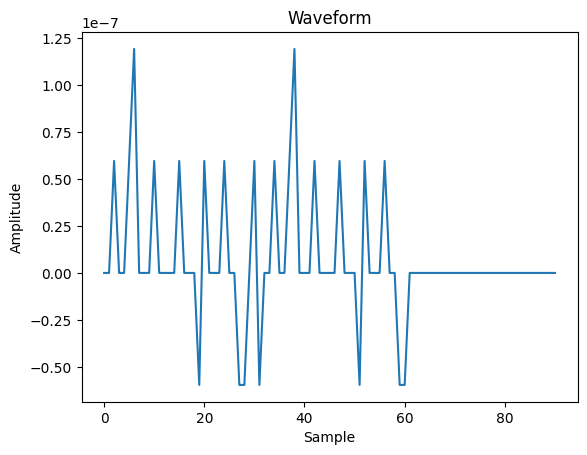

In [13]:
import matplotlib.pyplot as plt

plt.plot(a[115168-30:115199+30])
plt.title("Waveform")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()


In [18]:
testbench.data_manager.get_nodes_by_depth(1)[0].get_path()

'./artifacts-storage/Blues_piano-lost_samples_masks/BinomialPLS-52488861460455829'

In [ ]:
import numpy


numpy.load('./artifacts-storage/Blues_piano-lost_samples_masks/BinomialPLS-52488861460455829.npy'
, allow_pickle=True)

FileNotFoundError: [Errno 2] No such file or directory: './artifacts-storage/Blues_piano-lost_samples_masks/BinomialPLS-52488861460455829-reconstructed_tracks/ZerosPLC-2227333256375707.npy'